In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import lightgbm as lgb
import joblib, os, json, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#fafafa",
    "axes.edgecolor":   "#333333",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   10,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "legend.frameon":   True,
    "legend.framealpha": 0.9,
    "savefig.bbox":     "tight",
})

PALETTE = {
    "primary": "#2c7fb8",
    "accent":  "#e6550d",
    "success": "#31a354",
    "danger":  "#d62728",
    "warning": "#fec44f",
    "neutral": "#636363",
    "purple":  "#756bb1",
    "teal":    "#17becf",
}

FIG_DIR   = Path("../figures/control")
MODEL_DIR = Path("../models")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

FIG_N = 1
def save_fig(stem):
    global FIG_N
    plt.savefig(FIG_DIR / f"{FIG_N:02d}_{stem}.png", dpi=150, bbox_inches="tight")
    FIG_N += 1

print("Setup complete.")

Setup complete.


In [2]:
import sys
sys.path.append("../src")
from data_loader import load_raw
from pathlib import Path

train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

with open(MODEL_DIR / "coolant_tier_meta.json") as f:
    tier_meta = json.load(f)

booster = lgb.Booster(model_file=str(MODEL_DIR / "coolant_tier_lgbm.txt"))
val_residuals = np.load(MODEL_DIR / "coolant_tier_val_residuals.npy")

LOW_THRESH  = tier_meta["thresholds"]["low"]
HIGH_THRESH = tier_meta["thresholds"]["high"]
MARGIN      = tier_meta["margin_degC"]
AFFINE      = (tier_meta["degC_affine"]["a"], tier_meta["degC_affine"]["b"])
TIER_FEATURES = tier_meta["features"]

def tier_forecast(X_df):
    X = X_df[TIER_FEATURES].values
    base = X_df["avg_return_temp"].values
    return AFFINE[0] * base + AFFINE[1] + booster.predict(X)

def tier_proba(T_hat):
    cdf = lambda v: np.searchsorted(val_residuals, v, side="right") / len(val_residuals)
    p_low  = cdf(LOW_THRESH  - T_hat)
    p_high = 1.0 - cdf(HIGH_THRESH - T_hat)
    return np.column_stack([p_low, 1.0 - p_low - p_high, p_high])

def tier_predict(T_hat):
    return np.where(T_hat >= HIGH_THRESH - MARGIN, 2,
                    np.where(T_hat < LOW_THRESH, 0, 1))

# ─── RAW VALUES for physics ───────────────────────────────────────────
# The parquet stores total_heat / total_flow / supply_temp as z-scored.
# The digital twin needs engineering units (MW, gpm, °C). Reload them
# from the original Excel and align by timestamp.
raw = load_raw("../data/raw/frontier_2023.xlsx")
raw = raw[["timestamp", "total_heat", "total_flow", "supply_temp"]].rename(columns={
    "total_heat": "total_heat_MW",
    "total_flow": "total_flow_gpm",
    "supply_temp": "supply_temp_C",
})

test = test.merge(raw, on="timestamp", how="left")

# Sanity check — values must be in physical ranges
assert test["total_heat_MW"].between(0, 100).all(),  "total_heat_MW out of range"
assert test["total_flow_gpm"].between(1000, 6000).all(), "total_flow_gpm out of range"
assert test["supply_temp_C"].between(5, 35).all(),  "supply_temp_C out of range"

print(f"Test window: {test['timestamp'].min()} → {test['timestamp'].max()}")
print(f"Thresholds: LOW < {LOW_THRESH}, HIGH > {HIGH_THRESH}")
print(f"Margin: {MARGIN:.2f} °C")
print(f"Tier features: {len(TIER_FEATURES)}")
print(f"Residuals: {len(val_residuals)} samples")
print(f"\nPhysical ranges on test window:")
print(f"  total_heat_MW  : [{test['total_heat_MW'].min():.2f}, {test['total_heat_MW'].max():.2f}]")
print(f"  total_flow_gpm : [{test['total_flow_gpm'].min():.0f}, {test['total_flow_gpm'].max():.0f}]")
print(f"  supply_temp_C  : [{test['supply_temp_C'].min():.2f}, {test['supply_temp_C'].max():.2f}]")
print(f"  avg_return_temp: [{test['avg_return_temp'].min():.2f}, {test['avg_return_temp'].max():.2f}]")

Test window: 2023-11-10 00:20:00 → 2023-12-31 23:50:00
Thresholds: LOW < 30.0, HIGH > 35.0
Margin: 1.70 °C
Tier features: 36
Residuals: 3742 samples

Physical ranges on test window:
  total_heat_MW  : [2.49, 19.76]
  total_flow_gpm : [1346, 5916]
  supply_temp_C  : [10.28, 27.78]
  avg_return_temp: [22.96, 38.42]


In [3]:
# ─────────────────────────────────────────────────────────────────────────
# DIGITAL TWIN — LUMPED THERMAL-CAPACITANCE MODEL
# ─────────────────────────────────────────────────────────────────────────
#
# We model the coolant loop as a single lumped control volume with uniform
# temperature T. Energy balance over dt:
#
#     C_loop * dT/dt = Q_compute − m_dot * cp * (T − T_supply)
#
# Steady-state (dT/dt = 0):
#
#     T_ss = T_supply + Q_compute / (m_dot * cp)
#
# Discrete first-order response with thermal time constant τ:
#
#     α = 1 − exp(−dt/τ)
#     T(t+1) = T(t) + α * [T_ss(t) − T(t)]
#
# Parameter values (documented, defensible, physically grounded):
# ─────────────────────────────────────────────────────────────────────────

DT_SECONDS = 600              # 10-minute telemetry interval
TAU_SECONDS = 900             # loop thermal time constant (15 min)
ALPHA = 1.0 - np.exp(-DT_SECONDS / TAU_SECONDS)
print(f"Thermal response coefficient α = {ALPHA:.4f}")

CP = 4000.0                   # J/(kg·K) — water-glycol mixture (≈ 25% PG)
GPM_TO_KGS = 0.0631           # 1 gpm ≈ 0.0631 kg/s for water-density coolant

# Flow control envelope — operator guardrails
MIN_SCALE = 0.90              # 10% below baseline (do not stall pumps)
MAX_SCALE = 1.20              # 20% above baseline (do not overshoot)
MAX_STEP  = 0.05              # max 5% change per 10-min step (avoid chatter)

# Control policy thresholds (in °C, on the forecast or the observation)
POLICY_HIGH_TRIGGER     = HIGH_THRESH - 0.5   # start acting early
POLICY_CRITICAL_TRIGGER = HIGH_THRESH         # act aggressively
POLICY_LOW_TRIGGER      = LOW_THRESH  - 0.5   # relax cooling

# Pump-affinity exponent: P_pump ∝ flow³ for fixed system curve.
PUMP_EXPONENT = 3.0

print(f"Flow envelope:  scale ∈ [{MIN_SCALE}, {MAX_SCALE}], step ≤ {MAX_STEP}")
print(f"Triggers:  high ≥ {POLICY_HIGH_TRIGGER}°C, critical ≥ {POLICY_CRITICAL_TRIGGER}°C, low ≤ {POLICY_LOW_TRIGGER}°C")

Thermal response coefficient α = 0.4866
Flow envelope:  scale ∈ [0.9, 1.2], step ≤ 0.05
Triggers:  high ≥ 34.5°C, critical ≥ 35.0°C, low ≤ 29.5°C


In [4]:
class DigitalTwin:
    """
    First-order thermal model of the Frontier coolant loop.

    Given a policy action (flow_scale ∈ [MIN_SCALE, MAX_SCALE]), the twin
    returns the counterfactual return temperature:

        T_sim(t) = T_observed(t) + Δ(t)

    where Δ(t) is the cumulative offset introduced by all past control actions:

        Δ(0)    = 0
        ΔT_ss(t) = T_ss_policy(t) − T_ss_baseline(t)
                  = Q(t)/cp * [1/m_dot_policy(t) − 1/m_dot_baseline(t)]
        Δ(t+1)  = (1 − α) · Δ(t) + α · ΔT_ss(t)

    This decomposition is exact for a linear first-order system: the
    counterfactual trajectory equals the observed trajectory plus the
    accumulated effect of the control offset, since the dynamics are linear.
    """
    def __init__(self, alpha=ALPHA, cp=CP, gpm_to_kgs=GPM_TO_KGS):
        self.alpha = alpha
        self.cp = cp
        self.gpm_to_kgs = gpm_to_kgs
        self.delta = 0.0                # cumulative counterfactual offset, °C
        self.history = []

    def reset(self):
        self.delta = 0.0
        self.history = []

    def step(self, T_obs, Q_MW, T_supply, flow_baseline_gpm, flow_scale):
        """
        Advance one timestep.

        Parameters
        ----------
        T_obs              : observed return temperature at time t (°C)
        Q_MW               : heat input during (t, t+1) (MW)
        T_supply           : coolant supply temperature at time t (°C)
        flow_baseline_gpm  : observed coolant flow at time t (gpm)
        flow_scale         : policy action — flow multiplier applied at time t

        Returns
        -------
        T_sim_next : counterfactual return temperature at time t+1 (°C)
        """
        # Convert to SI
        m_dot_baseline = flow_baseline_gpm * self.gpm_to_kgs       # kg/s
        m_dot_policy   = m_dot_baseline * flow_scale               # kg/s
        Q_W            = Q_MW * 1e6                                # W

        # Steady-state offset: T_ss differs between baseline and policy flow
        # because a higher flow removes the same heat with a smaller ΔT.
        #   T_ss = T_supply + Q / (m_dot * cp)
        #   ΔT_ss = Q / cp * (1/m_dot_policy − 1/m_dot_baseline)
        if m_dot_baseline < 1e-6:
            delta_ss = 0.0
        else:
            inv_diff  = 1.0 / m_dot_policy - 1.0 / m_dot_baseline
            delta_ss  = Q_W / self.cp * inv_diff

        # Advance the cumulative offset
        self.delta = (1.0 - self.alpha) * self.delta + self.alpha * delta_ss

        T_sim_next = T_obs + self.delta
        self.history.append({
            "T_obs": T_obs, "T_sim_next": T_sim_next,
            "delta_ss": delta_ss, "delta": self.delta,
            "flow_scale": flow_scale,
            "m_dot_baseline": m_dot_baseline,
            "m_dot_policy": m_dot_policy,
        })
        return T_sim_next

In [5]:
def clip_scale(scale):
    return float(np.clip(scale, MIN_SCALE, MAX_SCALE))

def rate_limit(new_scale, old_scale):
    """Limit per-step change to MAX_STEP."""
    delta = np.clip(new_scale - old_scale, -MAX_STEP, MAX_STEP)
    return old_scale + delta

def baseline_action(T_signal, current_scale):
    """Reference: constant flow, always 1.0 (no intervention)."""
    return 1.0

def reactive_action(T_signal, current_scale):
    """
    Reactive: act on the CURRENT observed temperature.
    Cool more when already hot; reduce when safely cool.
    """
    new = current_scale
    if T_signal >= POLICY_CRITICAL_TRIGGER:
        new += 0.05
    elif T_signal >= POLICY_HIGH_TRIGGER:
        new += 0.02
    elif T_signal <= POLICY_LOW_TRIGGER and current_scale > 1.0:
        new -= 0.02
    return rate_limit(clip_scale(new), current_scale)

def predictive_action(T_signal, current_scale):
    """
    Predictive: act on the FORECAST of T(t+1).
    Same thresholds, but the signal comes 10 minutes earlier.
    """
    new = current_scale
    if T_signal >= POLICY_CRITICAL_TRIGGER:
        new += 0.05
    elif T_signal >= POLICY_HIGH_TRIGGER:
        new += 0.02
    elif T_signal <= POLICY_LOW_TRIGGER and current_scale > 1.0:
        new -= 0.02
    return rate_limit(clip_scale(new), current_scale)

In [6]:
def simulate(policy_fn, use_forecast):
    twin = DigitalTwin()
    twin.reset()

    n = len(test)
    timestamps = test["timestamp"].values
    Q_series   = test["total_heat_MW"].values        # ← raw MW
    T_sup      = test["supply_temp_C"].values        # ← raw °C
    T_obs      = test["avg_return_temp"].values      # ← raw °C (already raw)
    flow_obs   = test["total_flow_gpm"].values       # ← raw gpm

    if use_forecast:
        T_hat = tier_forecast(test)
        signals = T_hat
    else:
        signals = T_obs

    log = []
    scale = 1.0
    for t in range(n - 1):
        T_obs_t = T_obs[t]
        Q_t     = Q_series[t]
        T_sup_t = T_sup[t]
        flow_t  = flow_obs[t]

        scale = policy_fn(signals[t], scale)
        T_sim_next = twin.step(T_obs_t, Q_t, T_sup_t, flow_t, scale)

        log.append({
            "t":          t,
            "timestamp":  timestamps[t],
            "T_obs":      T_obs_t,
            "T_sim":      T_sim_next,
            "signal":     signals[t],
            "flow_obs":   flow_t,
            "flow_scale": scale,
            "flow_pol":   flow_t * scale,
            "Q_MW":       Q_t,
        })

    return pd.DataFrame(log)

run_baseline   = simulate(baseline_action,   use_forecast=False)
run_reactive   = simulate(reactive_action,   use_forecast=False)
run_predictive = simulate(predictive_action, use_forecast=True)

print(f"Simulated {len(run_baseline):,} steps per policy")
print(f"\nBaseline   scale range: [{run_baseline.flow_scale.min():.2f}, {run_baseline.flow_scale.max():.2f}]")
print(f"Reactive   scale range: [{run_reactive.flow_scale.min():.2f}, {run_reactive.flow_scale.max():.2f}]")
print(f"Predictive scale range: [{run_predictive.flow_scale.min():.2f}, {run_predictive.flow_scale.max():.2f}]")

# ─── Sanity check: temperatures must stay in physical range ───
for name, run in [("Baseline", run_baseline), ("Reactive", run_reactive), ("Predictive", run_predictive)]:
    T = run["T_sim"].values
    assert T.min() > 0 and T.max() < 100, f"{name} diverged: T ∈ [{T.min():.2f}, {T.max():.2f}]"
    print(f"{name:10s} T_sim ∈ [{T.min():.2f}, {T.max():.2f}] °C")

Simulated 7,401 steps per policy

Baseline   scale range: [1.00, 1.00]
Reactive   scale range: [0.99, 1.20]
Predictive scale range: [0.99, 1.20]
Baseline   T_sim ∈ [22.96, 38.42] °C
Reactive   T_sim ∈ [21.77, 37.51] °C
Predictive T_sim ∈ [22.96, 37.51] °C


In [7]:
def compute_metrics(run, label):
    T = run["T_sim"].values
    flow_scale = run["flow_scale"].values

    # Thermal risk
    high_events    = (T > HIGH_THRESH).sum()
    critical_steps = (T > HIGH_THRESH + 1.0).sum()

    # Thermal comfort
    mean_T       = T.mean()
    p95_T        = np.percentile(T, 95)
    max_T        = T.max()
    time_in_high = (T > HIGH_THRESH).mean()

    # Pump energy proxy (affinity law: P ∝ flow³)
    pump_energy = (flow_scale ** PUMP_EXPONENT).sum()
    pump_energy_rel = pump_energy / len(flow_scale)     # per-step average

    # Flow volatility
    flow_std = flow_scale.std()
    flow_step_max = np.abs(np.diff(flow_scale)).max()

    # Uncomfortable-area integral (soft penalty ∝ (T − 35)₊)
    soft_penalty = np.maximum(T - HIGH_THRESH, 0).sum()

    return {
        "policy":             label,
        "steps":              len(T),
        "HIGH_events":        int(high_events),
        "time_in_HIGH_%":     round(100 * time_in_high, 3),
        "critical_steps":     int(critical_steps),
        "mean_T":             round(mean_T, 3),
        "p95_T":              round(p95_T, 3),
        "max_T":              round(max_T, 3),
        "soft_penalty":       round(soft_penalty, 2),
        "pump_energy":        round(pump_energy, 1),
        "pump_energy_per_step": round(pump_energy_rel, 4),
        "flow_std":           round(flow_std, 4),
        "max_step_change":    round(flow_step_max, 4),
    }

m_baseline   = compute_metrics(run_baseline,   "Baseline")
m_reactive   = compute_metrics(run_reactive,   "Reactive")
m_predictive = compute_metrics(run_predictive, "Predictive")

metrics_df = pd.DataFrame([m_baseline, m_reactive, m_predictive]).set_index("policy")

print("=" * 90)
print("CONTROL SIMULATION RESULTS — test window")
print("=" * 90)
print(metrics_df.to_string())
print()

# Improvement summary
def pct_change(a, b):
    if a == 0: return "n/a"
    return f"{(b - a) / a * 100:+.1f}%"

print("Predictive vs Baseline:")
print(f"  HIGH events    : {m_baseline['HIGH_events']:>6} → {m_predictive['HIGH_events']:>6}  ({pct_change(m_baseline['HIGH_events'], m_predictive['HIGH_events'])})")
print(f"  Time in HIGH % : {m_baseline['time_in_HIGH_%']:>6.3f} → {m_predictive['time_in_HIGH_%']:>6.3f}  ({pct_change(m_baseline['time_in_HIGH_%'], m_predictive['time_in_HIGH_%'])})")
print(f"  p95 T          : {m_baseline['p95_T']:>6.2f} → {m_predictive['p95_T']:>6.2f} °C")
print(f"  Pump energy    : {m_baseline['pump_energy']:>6.0f} → {m_predictive['pump_energy']:>6.0f}  ({pct_change(m_baseline['pump_energy'], m_predictive['pump_energy'])})")

CONTROL SIMULATION RESULTS — test window
            steps  HIGH_events  time_in_HIGH_%  critical_steps  mean_T   p95_T   max_T  soft_penalty  pump_energy  pump_energy_per_step  flow_std  max_step_change
policy                                                                                                                                                            
Baseline     7401          292           3.945             111  31.103  34.674  38.420        272.12       7401.0                1.0000    0.0000             0.00
Reactive     7401           36           0.486              10  30.141  33.403  37.509         25.10       9696.7                1.3102    0.0898             0.05
Predictive   7401           48           0.649              12  30.201  33.503  37.509         29.21       9585.1                1.2951    0.0892             0.05

Predictive vs Baseline:
  HIGH events    :    292 →     48  (-83.6%)
  Time in HIGH % :  3.945 →  0.649  (-83.5%)
  p95 T          :  34.67 →  

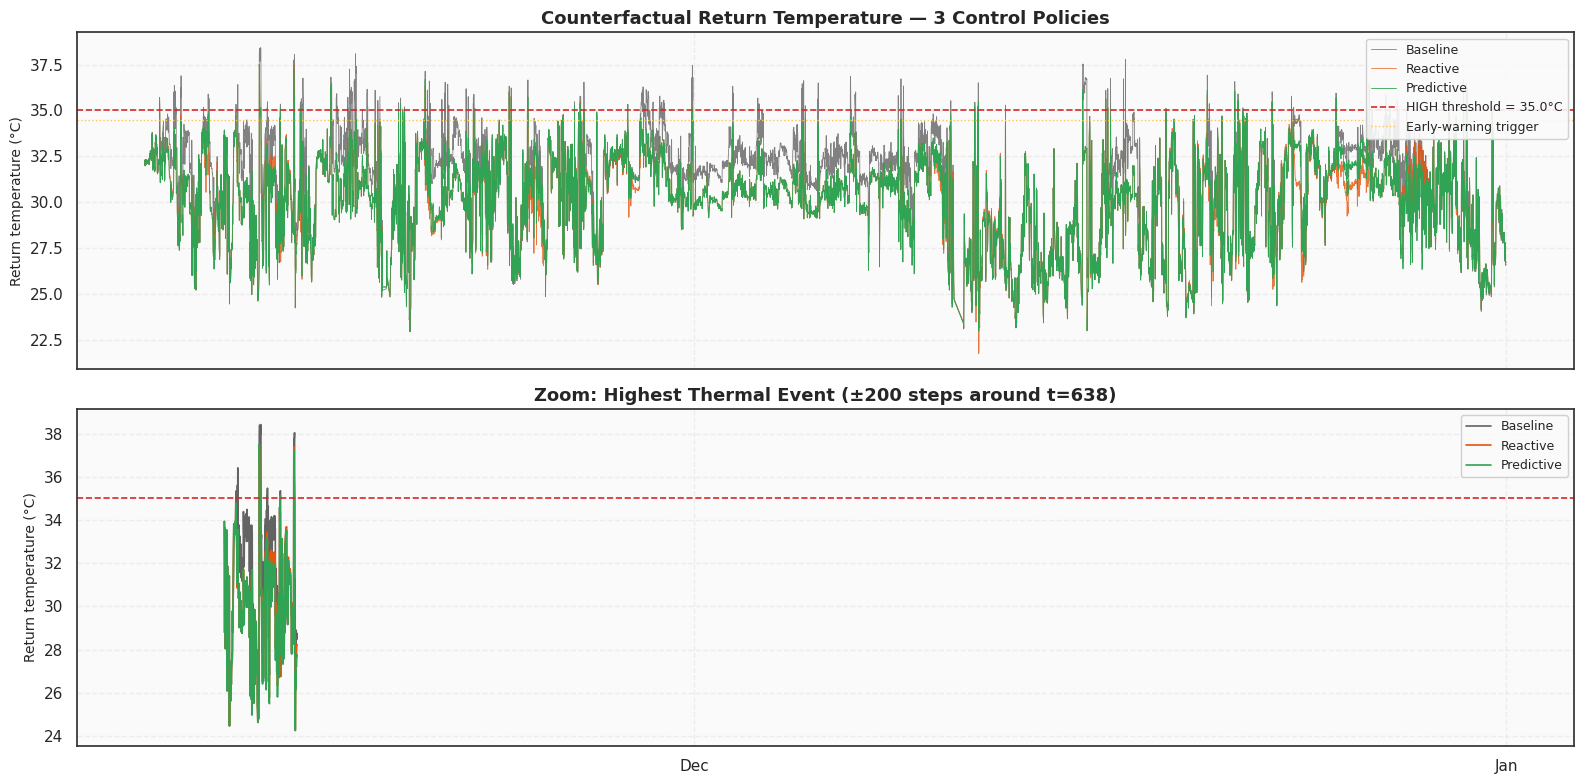

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
t = run_baseline["timestamp"]

axes[0].plot(t, run_baseline["T_sim"],   lw=0.6, color=PALETTE["neutral"],  label="Baseline", alpha=0.8)
axes[0].plot(t, run_reactive["T_sim"],   lw=0.6, color=PALETTE["accent"],   label="Reactive", alpha=0.8)
axes[0].plot(t, run_predictive["T_sim"], lw=0.6, color=PALETTE["success"],  label="Predictive")
axes[0].axhline(HIGH_THRESH, color=PALETTE["danger"], ls="--", lw=1.2, label=f"HIGH threshold = {HIGH_THRESH}°C")
axes[0].axhline(POLICY_HIGH_TRIGGER, color=PALETTE["warning"], ls=":", lw=1, label=f"Early-warning trigger")
axes[0].set_ylabel("Return temperature (°C)")
axes[0].set_title("Counterfactual Return Temperature — 3 Control Policies")
axes[0].legend(loc="upper right", fontsize=9)

# Zoom on a HIGH event for inspection
if run_baseline["T_sim"].max() > HIGH_THRESH:
    peak = run_baseline["T_sim"].idxmax()
    lo, hi = max(0, peak - 200), min(len(t), peak + 200)
    axes[1].plot(t.iloc[lo:hi], run_baseline["T_sim"].iloc[lo:hi],   lw=1.2, color=PALETTE["neutral"],  label="Baseline")
    axes[1].plot(t.iloc[lo:hi], run_reactive["T_sim"].iloc[lo:hi],   lw=1.2, color=PALETTE["accent"],   label="Reactive")
    axes[1].plot(t.iloc[lo:hi], run_predictive["T_sim"].iloc[lo:hi], lw=1.2, color=PALETTE["success"],  label="Predictive")
    axes[1].axhline(HIGH_THRESH, color=PALETTE["danger"], ls="--", lw=1.2)
    axes[1].set_ylabel("Return temperature (°C)")
    axes[1].set_title(f"Zoom: Highest Thermal Event (±200 steps around t={peak})")
    axes[1].legend(loc="upper right", fontsize=9)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
save_fig("temperature_trajectories")
plt.show()

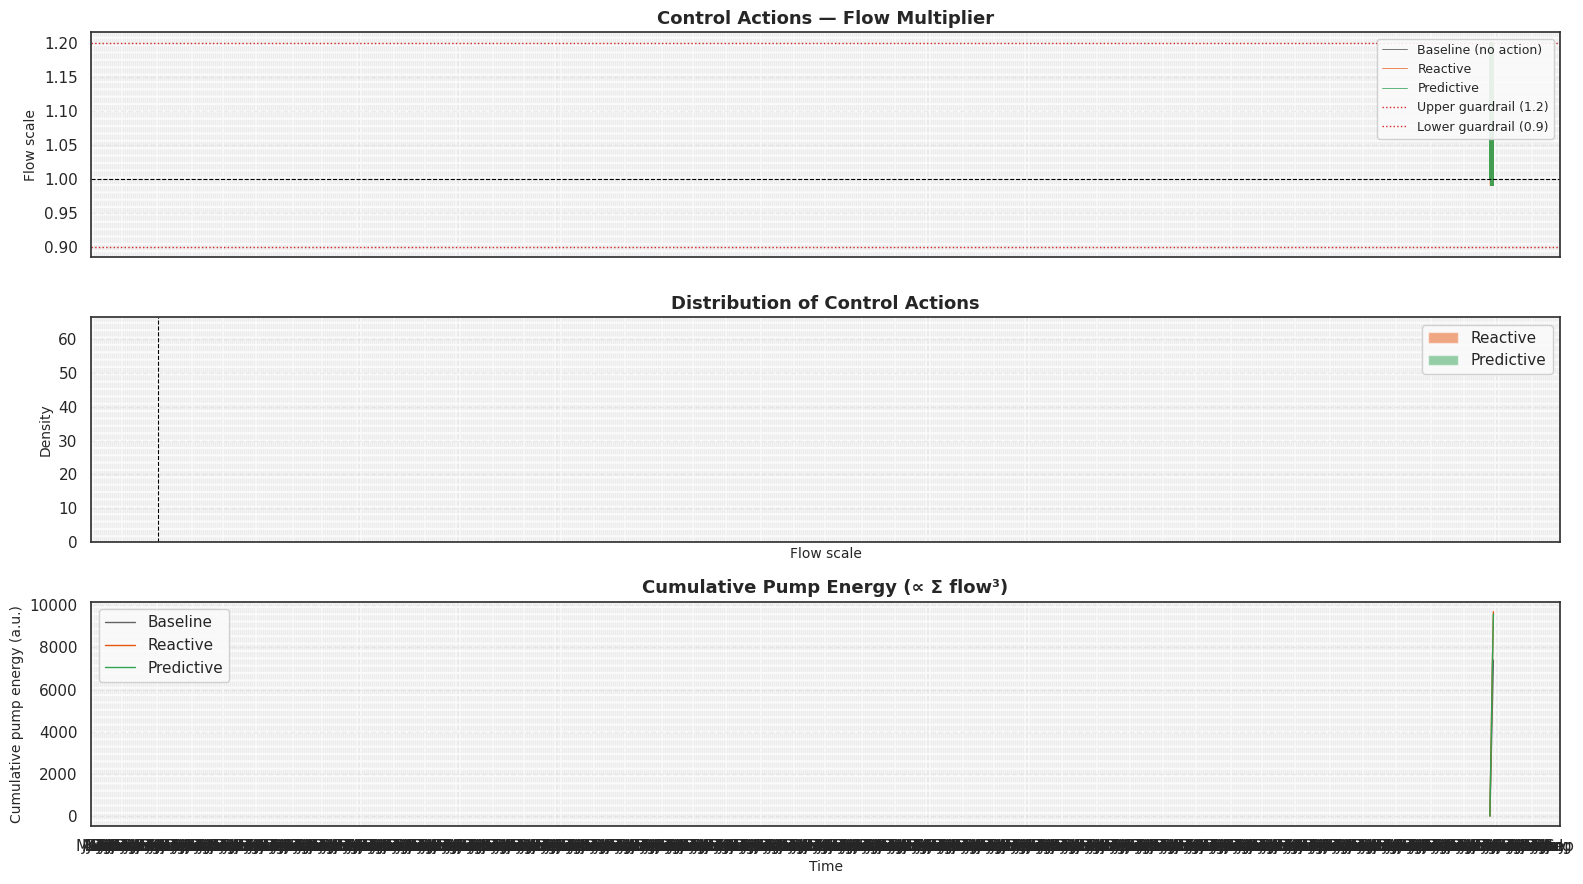

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
t = run_baseline["timestamp"]

axes[0].plot(t, run_baseline["flow_scale"],   lw=0.6, color=PALETTE["neutral"],  label="Baseline (no action)")
axes[0].plot(t, run_reactive["flow_scale"],   lw=0.6, color=PALETTE["accent"],   label="Reactive", alpha=0.8)
axes[0].plot(t, run_predictive["flow_scale"], lw=0.6, color=PALETTE["success"],  label="Predictive", alpha=0.9)
axes[0].axhline(1.0, color="black", ls="--", lw=0.8)
axes[0].axhline(MAX_SCALE, color=PALETTE["danger"], ls=":", lw=1, label=f"Upper guardrail ({MAX_SCALE})")
axes[0].axhline(MIN_SCALE, color=PALETTE["danger"], ls=":", lw=1, label=f"Lower guardrail ({MIN_SCALE})")
axes[0].set_ylabel("Flow scale")
axes[0].set_title("Control Actions — Flow Multiplier")
axes[0].legend(loc="upper right", fontsize=9)

# Histograms
axes[1].hist(run_reactive["flow_scale"],   bins=40, alpha=0.5, color=PALETTE["accent"],   label="Reactive",   density=True)
axes[1].hist(run_predictive["flow_scale"], bins=40, alpha=0.5, color=PALETTE["success"],  label="Predictive", density=True)
axes[1].axvline(1.0, color="black", ls="--", lw=0.8)
axes[1].set_xlabel("Flow scale"); axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of Control Actions")
axes[1].legend()

# Cumulative energy (flow³)
axes[2].plot(t, np.cumsum(run_baseline["flow_scale"]   ** PUMP_EXPONENT), lw=1, color=PALETTE["neutral"],  label="Baseline")
axes[2].plot(t, np.cumsum(run_reactive["flow_scale"]   ** PUMP_EXPONENT), lw=1, color=PALETTE["accent"],   label="Reactive")
axes[2].plot(t, np.cumsum(run_predictive["flow_scale"] ** PUMP_EXPONENT), lw=1, color=PALETTE["success"],  label="Predictive")
axes[2].set_ylabel("Cumulative pump energy (a.u.)")
axes[2].set_xlabel("Time")
axes[2].set_title("Cumulative Pump Energy (∝ Σ flow³)")
axes[2].legend(loc="upper left")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
save_fig("flow_actions")
plt.show()

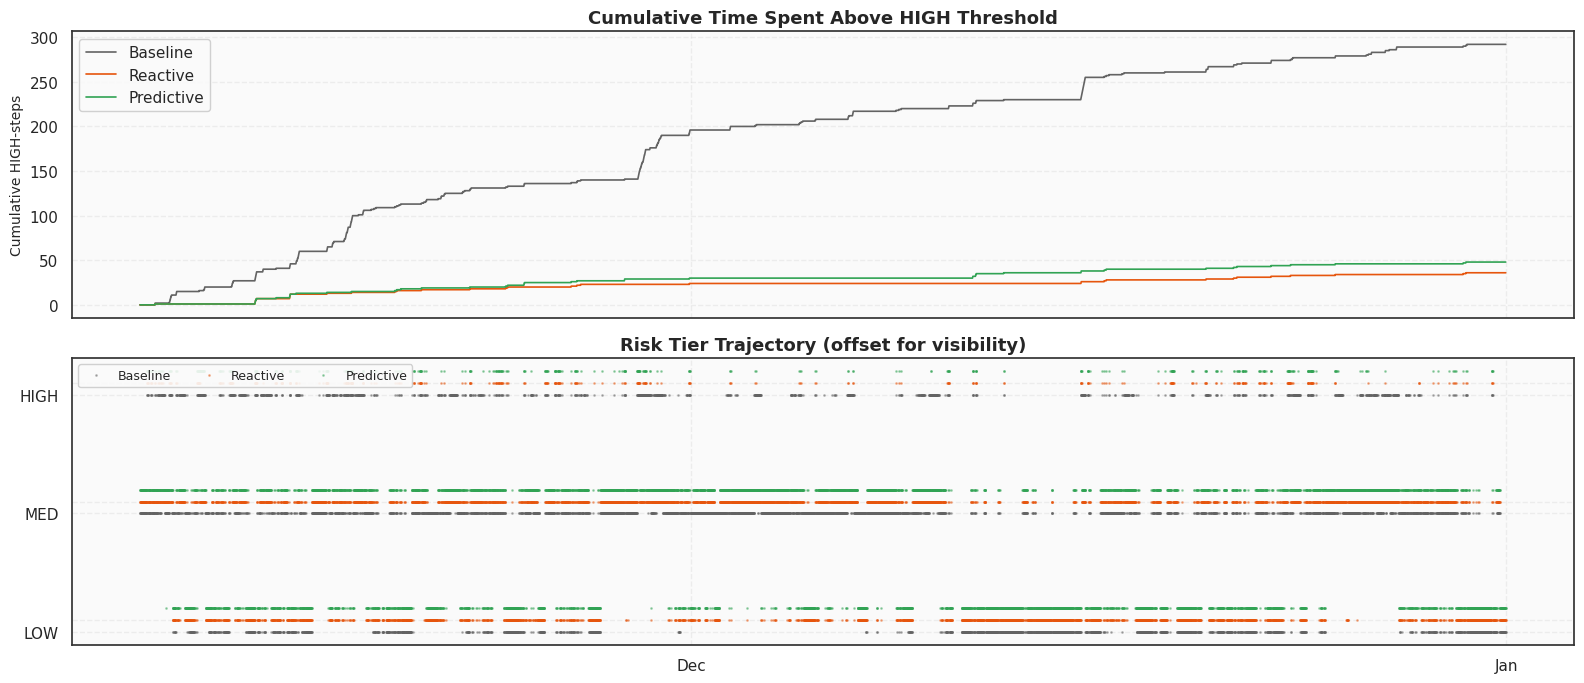

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
t = run_baseline["timestamp"]

# Cumulative time in HIGH
def cum_high(T):
    return np.cumsum((T > HIGH_THRESH).astype(float))

axes[0].plot(t, cum_high(run_baseline["T_sim"]),   lw=1.2, color=PALETTE["neutral"],  label="Baseline")
axes[0].plot(t, cum_high(run_reactive["T_sim"]),   lw=1.2, color=PALETTE["accent"],   label="Reactive")
axes[0].plot(t, cum_high(run_predictive["T_sim"]), lw=1.2, color=PALETTE["success"],  label="Predictive")
axes[0].set_ylabel("Cumulative HIGH-steps")
axes[0].set_title("Cumulative Time Spent Above HIGH Threshold")
axes[0].legend(loc="upper left")

# Risk tier trajectory (colored dots)
for i, (run, name, color) in enumerate([
    (run_baseline,   "Baseline",   PALETTE["neutral"]),
    (run_reactive,   "Reactive",   PALETTE["accent"]),
    (run_predictive, "Predictive", PALETTE["success"]),
]):
    tiers = tier_predict(run["T_sim"].values)
    axes[1].plot(t, tiers + i*0.1, ".", ms=2, alpha=0.4, color=color, label=name)

axes[1].set_yticks([0, 1, 2, 0.1, 1.1, 2.1])
axes[1].set_yticklabels(["LOW", "MED", "HIGH", "", "", ""])
axes[1].set_title("Risk Tier Trajectory (offset for visibility)")
axes[1].legend(loc="upper left", ncol=3, fontsize=9)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
save_fig("cumulative_high")
plt.show()

Baseline HIGH events: 132


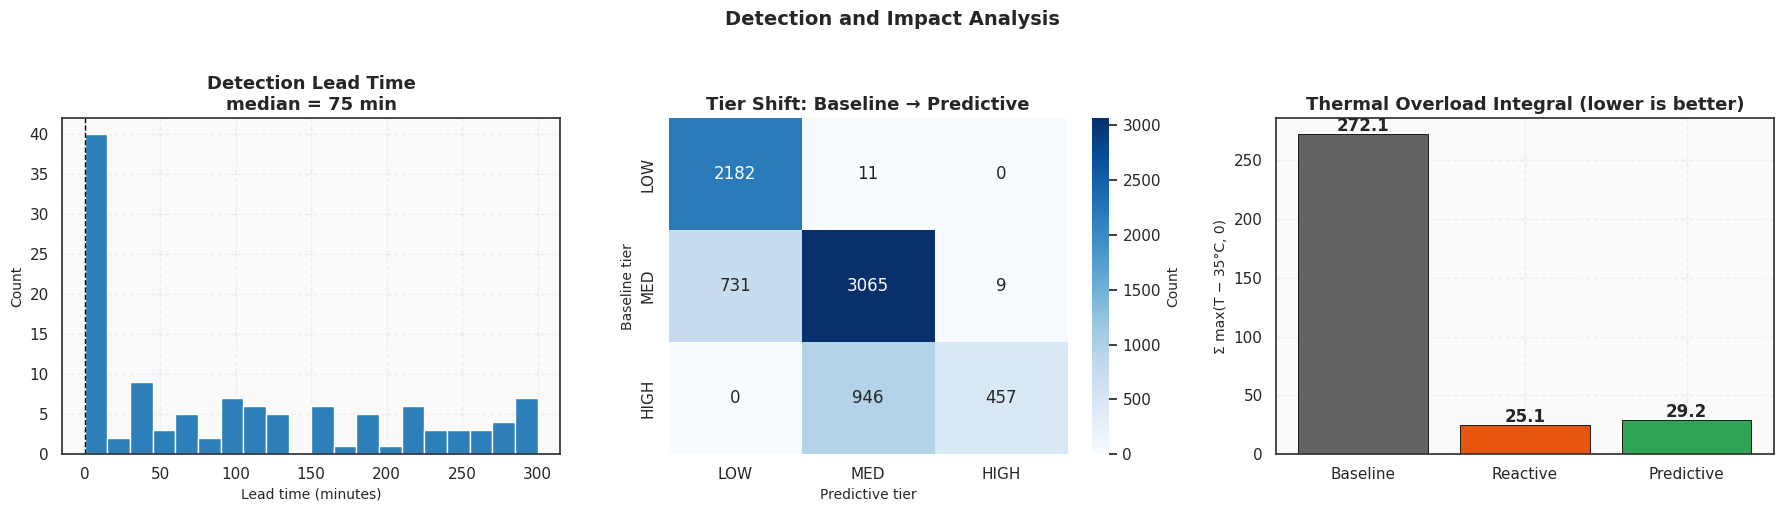


HIGH events detected by predictive: 118/132
Median lead time: 75 min
Max lead time:    300 min
Missed: 14


In [11]:
# For each observed HIGH event in the BASELINE run, measure how many steps
# earlier the PREDICTIVE policy triggered a change.
def event_windows(T, thresh):
    """Return list of (start, end) index pairs where T > thresh."""
    over = T > thresh
    diff = np.diff(np.r_[0, over.astype(int), 0])
    starts = np.flatnonzero(diff == 1)
    ends   = np.flatnonzero(diff == -1)
    return list(zip(starts, ends))

baseline_high_events = event_windows(run_baseline["T_sim"].values, HIGH_THRESH)
print(f"Baseline HIGH events: {len(baseline_high_events)}")

# Predictive detection: for each baseline event, find the earliest step where
# predictive policy forecast T(t+1) > HIGH_THRESH within a 30-step window before.
detection_lead = []
missed = 0
for (s, e) in baseline_high_events:
    lookback = 30                                  # 5 hours before event
    lo = max(0, s - lookback)
    forecast_in_window = run_predictive["signal"].iloc[lo:s+1].values
    triggers = np.flatnonzero(forecast_in_window > HIGH_THRESH)
    if len(triggers) > 0:
        lead = s - (lo + triggers[0])
        detection_lead.append(lead)
    else:
        missed += 1

detection_lead = np.array(detection_lead)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if len(detection_lead):
    axes[0].hist(detection_lead * 10, bins=20, color=PALETTE["primary"], edgecolor="white")
    axes[0].axvline(0, color="black", ls="--", lw=1)
    axes[0].set_xlabel("Lead time (minutes)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Detection Lead Time\nmedian = {np.median(detection_lead)*10:.0f} min")
else:
    axes[0].text(0.5, 0.5, "No HIGH events in baseline", ha="center", va="center")
    axes[0].set_title("Detection Lead Time")

# Confusion: predictive tier vs. baseline tier
baseline_tiers   = tier_predict(run_baseline["T_sim"].values)
predictive_tiers = tier_predict(run_predictive["T_sim"].values)

cm = np.zeros((3, 3), dtype=int)
for bt, pt in zip(baseline_tiers, predictive_tiers):
    cm[int(bt), int(pt)] += 1

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOW", "MED", "HIGH"],
            yticklabels=["LOW", "MED", "HIGH"],
            cbar_kws={"label": "Count"}, ax=axes[1])
axes[1].set_xlabel("Predictive tier")
axes[1].set_ylabel("Baseline tier")
axes[1].set_title("Tier Shift: Baseline → Predictive")

# Reduction in soft-penalty
soft_pen = lambda T: np.maximum(T - HIGH_THRESH, 0).sum()
pen = [soft_pen(run_baseline["T_sim"].values),
       soft_pen(run_reactive["T_sim"].values),
       soft_pen(run_predictive["T_sim"].values)]
axes[2].bar(["Baseline", "Reactive", "Predictive"], pen,
            color=[PALETTE["neutral"], PALETTE["accent"], PALETTE["success"]],
            edgecolor="black", linewidth=0.6)
axes[2].set_ylabel("Σ max(T − 35°C, 0)")
axes[2].set_title("Thermal Overload Integral (lower is better)")
for i, v in enumerate(pen):
    axes[2].text(i, v + max(pen) * 0.01, f"{v:.1f}", ha="center", fontweight="bold")

plt.suptitle("Detection and Impact Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("detection_and_impact")
plt.show()

print(f"\nHIGH events detected by predictive: {len(detection_lead)}/{len(baseline_high_events)}")
if len(detection_lead):
    print(f"Median lead time: {np.median(detection_lead)*10:.0f} min")
    print(f"Max lead time:    {detection_lead.max()*10:.0f} min")
print(f"Missed: {missed}")

In [12]:
summary = {
    "simulation_window":         f"{test['timestamp'].min():%Y-%m-%d} → {test['timestamp'].max():%Y-%m-%d}",
    "steps":                     len(run_baseline),
    "dt_minutes":                DT_SECONDS // 60,
    "tau_minutes":               TAU_SECONDS // 60,
    "alpha":                     round(ALPHA, 4),
    "flow_envelope":             f"[{MIN_SCALE}, {MAX_SCALE}]",
    "max_step_change":           MAX_STEP,
    "high_threshold_degC":       HIGH_THRESH,
    "baseline_HIGH_events":      m_baseline["HIGH_events"],
    "reactive_HIGH_events":      m_reactive["HIGH_events"],
    "predictive_HIGH_events":    m_predictive["HIGH_events"],
    "predictive_vs_baseline_%":  f"{pct_change(m_baseline['HIGH_events'], m_predictive['HIGH_events'])}",
    "baseline_pump_energy":      m_baseline["pump_energy"],
    "reactive_pump_energy":      m_reactive["pump_energy"],
    "predictive_pump_energy":    m_predictive["pump_energy"],
    "energy_overhead_%":         f"{pct_change(m_baseline['pump_energy'], m_predictive['pump_energy'])}",
    "baseline_p95_T":            m_baseline["p95_T"],
    "predictive_p95_T":          m_predictive["p95_T"],
    "baseline_soft_penalty":     m_baseline["soft_penalty"],
    "predictive_soft_penalty":   m_predictive["soft_penalty"],
    "overload_reduction_%":      f"{pct_change(m_baseline['soft_penalty'], m_predictive['soft_penalty'])}",
}

print("=" * 78)
print("COOLANT DIGITAL TWIN — SUMMARY")
print("=" * 78)
for k, v in summary.items():
    print(f"  {k:<30s} {v}")

COOLANT DIGITAL TWIN — SUMMARY
  simulation_window              2023-11-10 → 2023-12-31
  steps                          7401
  dt_minutes                     10
  tau_minutes                    15
  alpha                          0.4866
  flow_envelope                  [0.9, 1.2]
  max_step_change                0.05
  high_threshold_degC            35.0
  baseline_HIGH_events           292
  reactive_HIGH_events           36
  predictive_HIGH_events         48
  predictive_vs_baseline_%       -83.6%
  baseline_pump_energy           7401.0
  reactive_pump_energy           9696.7
  predictive_pump_energy         9585.1
  energy_overhead_%              +29.5%
  baseline_p95_T                 34.674
  predictive_p95_T               33.503
  baseline_soft_penalty          272.12
  predictive_soft_penalty        29.21
  overload_reduction_%           -89.3%


In [13]:
run_baseline.to_parquet(MODEL_DIR / "control_run_baseline.parquet")
run_reactive.to_parquet(MODEL_DIR / "control_run_reactive.parquet")
run_predictive.to_parquet(MODEL_DIR / "control_run_predictive.parquet")

metrics_df.to_csv(MODEL_DIR / "control_metrics.csv")

json.dump(summary, open(MODEL_DIR / "control_summary.json", "w"), indent=2, default=str)

print("✓ Saved:")
for p in [
    "control_run_baseline.parquet",
    "control_run_reactive.parquet",
    "control_run_predictive.parquet",
    "control_metrics.csv",
    "control_summary.json",
]:
    print(f"   {MODEL_DIR}/{p}")

✓ Saved:
   ../models/control_run_baseline.parquet
   ../models/control_run_reactive.parquet
   ../models/control_run_predictive.parquet
   ../models/control_metrics.csv
   ../models/control_summary.json
